# 1.实验验证阶段

本项目是基于马科维兹现代投资组合理论打造的美股投资组合优化工具，程序通过 tkinter 搭建了简洁的图形交互界面，支持用户自定义数据时间范围、自主选择多只美股标的，可自动获取真实市场数据并完成有效前沿计算，精准定位最优夏普比率组合与最小方差组合，最终以可视化图表搭配控制台文本的形式，完整输出投资组合的优化分析结果。
该工具的核心逻辑遵循马科维兹有效前沿理论，核心思路是通过分散投资实现风险与收益的最优匹配，即在固定风险水平下追求收益最大化，或是在固定收益目标下将风险降至最低，程序依托股票历史收益率数据构建协方差矩阵，借助数值优化算法求解有效前沿曲线，同时筛选出两类关键组合，分别是风险调整后收益表现最优的夏普比率组合，以及整体投资风险最低的最小方差组合。
程序的整体执行流程清晰连贯，运行后会先完成 Matplotlib 的中文与负号显示适配，避免可视化乱码问题，随后弹出交互窗口引导用户输入符合 YYYY-MM-DD 格式的起止日期，并选择至少两只美股股票；数据获取环节会优先通过 yfinance 库拉取雅虎财经的美股真实日度收盘价数据，若出现网络或接口异常，会自动切换为贴合美股收益特征的模拟本地数据；拿到有效收益率数据后，程序会计算个股平均收益率与协方差矩阵，生成 10000 组随机投资组合并分别计算收益、风险和夏普比率，再通过 scipy 的优化算法求解有效前沿、最优夏普组合和最小方差组合，最后完成图表绘制与控制台指标输出，呈现完整的优化结果。
项目运行依赖 numpy、pandas、matplotlib、scipy、tkinter、yfinance、datetime 等 Python 库，其中美股真实行情数据来源于 yfinance 开源接口，该库对接雅虎财经数据源，官方链接为https://pypi.org/project/yfinance/。使用时需先通过 pip 命令安装全部依赖库，运行主程序后按照弹窗提示完成日期输入和股票选择，等待程序完成数据下载与数值计算，即可自动查看可视化分析图表，同时在控制台获取详细的组合优化数据。
程序最终会输出两类核心结果，可视化部分会展示随机投资组合的散点分布、红色的有效前沿曲线，用红星标注最优组合、蓝点标注最小方差组合，还会搭配夏普比率色标和组合权重标注；控制台则会清晰打印最优组合与最小方差组合的年化收益率、波动率、夏普比率，以及最优组合中各只股票的具体权重分配比例，直观呈现投资组合优化方案。

In [ ]:
 -*- coding: utf-8 -*-
"""
马科维兹有效前沿 - 带时间和股票输入窗口版
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
import time
import tkinter as tk
from tkinter import simpledialog, messagebox, Listbox, MULTIPLE, Button, Label
from datetime import datetime
warnings.filterwarnings('ignore')

# ======================== 1. 中文显示配置 ========================
def setup_chinese_font():
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示
    font_list = ['Microsoft YaHei', 'SimHei', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
    for font in font_list:
        try:
            plt.rcParams['font.sans-serif'] = [font]
            break
        except:
            continue

setup_chinese_font()

# ======================== 2. 股票列表（来自图片） ========================
ALL_STOCK_INFO = {
    'AAPL': {'name': '苹果'},
    'MSFT': {'name': '微软'},
    'GOOGL': {'name': '谷歌'},
    'AMZN': {'name': '亚马逊'},
    'TSLA': {'name': '特斯拉'},
    'META': {'name': '元宇宙'},
    'NVDA': {'name': '英伟达'},
    'JPM': {'name': '摩根大通'},
    'V': {'name': '维萨'},
    'WMT': {'name': '沃尔玛'},
    'PG': {'name': '宝洁'},
    'KO': {'name': '可口可乐'},
    'DIS': {'name': '迪士尼'},
    'XOM': {'name': '埃克森美孚'},
    'BABA': {'name': '阿里巴巴'}
}

# ======================== 3. 新增：时间与股票输入窗口 ========================
def get_date_input():
    """获取用户输入的时间范围"""
    root = tk.Tk()
    root.withdraw()
    default_start = '2016-01-01'
    default_end = '2026-01-03'
    
    try:
        # 开始时间
        while True:
            start_date = simpledialog.askstring(
                title="开始时间",
                prompt=f"请输入数据开始日期（格式：YYYY-MM-DD）\n默认值：{default_start}",
                initialvalue=default_start
            )
            if start_date is None: return None, None
            if start_date.strip() == "": start_date = default_start
            try:
                datetime.strptime(start_date, '%Y-%m-%d')
                break
            except ValueError:
                messagebox.showerror("错误", "日期格式不正确！请使用 YYYY-MM-DD 格式")
        
        # 结束时间
        while True:
            end_date = simpledialog.askstring(
                title="结束时间",
                prompt=f"请输入数据结束日期（格式：YYYY-MM-DD）\n默认值：{default_end}",
                initialvalue=default_end
            )
            if end_date is None: return None, None
            if end_date.strip() == "": end_date = default_end
            try:
                datetime.strptime(end_date, '%Y-%m-%d')
                break
            except ValueError:
                messagebox.showerror("错误", "日期格式不正确！请使用 YYYY-MM-DD 格式")
        
        # 验证时间逻辑
        if datetime.strptime(start_date, '%Y-%m-%d') >= datetime.strptime(end_date, '%Y-%m-%d'):
            messagebox.showerror("错误", "开始日期不能晚于或等于结束日期！")
            return get_date_input()
        
        root.destroy()
        return start_date, end_date
    except Exception as e:
        messagebox.showerror("错误", f"获取时间失败：{str(e)}")
        root.destroy()
        return default_start, default_end

def get_selected_stocks():
    """让用户选择股票，提供多选列表"""
    root = tk.Tk()
    root.title("选择股票")
    root.geometry("500x400")
    
    Label(root, text="请选择要分析的股票（可多选）", font=("微软雅黑", 12)).pack(pady=10)
    
    # 股票列表
    stock_list = Listbox(root, selectmode=MULTIPLE, width=50, height=15, font=("微软雅黑", 10))
    for ticker, info in ALL_STOCK_INFO.items():
        stock_list.insert(tk.END, f"{ticker} - {info['name']}")
    stock_list.pack(pady=10)
    
    selected = []
    def on_confirm():
        nonlocal selected
        indices = stock_list.curselection()
        if len(indices) < 2:
            messagebox.showwarning("警告", "请至少选择2只股票以构建投资组合")
            return
        selected = [stock_list.get(i).split(" - ")[0] for i in indices]
        root.destroy()
    
    Button(root, text="确认选择", command=on_confirm, font=("微软雅黑", 10)).pack(pady=5)
    root.mainloop()
    
    return selected if selected else list(ALL_STOCK_INFO.keys())[:5]  # 默认选前5只

# ======================== 4. 美股真实数据获取 ========================
def get_us_stock_data():
    """从yfinance获取美股真实数据"""
    try:
        import yfinance as yf
        
        # 获取用户输入
        start_date, end_date = get_date_input()
        if start_date is None or end_date is None:
            print("用户取消输入，使用默认时间范围")
            start_date = '2016-01-01'
            end_date = '2026-01-03'
        
        selected_tickers = get_selected_stocks()
        print(f"📅 使用时间范围：{start_date} 至 {end_date}")
        print(f"📊 选择的股票：{selected_tickers}")
        
        # 下载数据
        data_list = []
        for ticker in selected_tickers:
            print(f"正在下载 {ticker} 数据...")
            df = yf.download(
                ticker, 
                start=start_date, 
                end=end_date, 
                progress=False,
                auto_adjust=True
            )
            if 'Close' in df.columns and not df['Close'].empty:
                data_list.append(df['Close'])
                print(f"✅ {ticker} 数据下载成功")
            else:
                print(f"❌ {ticker} 数据为空，跳过该标的")
            time.sleep(1)
        
        if len(data_list) < 2:
            raise ValueError("有效标的不足，无法构建投资组合")
        
        # 合并数据
        data = pd.concat(data_list, axis=1)
        data.columns = [ALL_STOCK_INFO[ticker]['name'] for ticker in selected_tickers[:len(data_list)]]
        data = data.dropna()
        returns_df = data.pct_change().dropna()
        
        print("✅ 成功获取美股真实数据")
        return returns_df
    
    except Exception as e:
        print(f"❌ 美股数据下载失败：{type(e).__name__} - {str(e)}")
        print("👉 自动切换到本地模拟数据")
        return generate_sim_data()

def generate_sim_data():
    """备用：模拟美股特征的数据集"""
    np.random.seed(42)
    n_assets = 7
    n_days = 252
    
    mean_returns = np.random.uniform(low=0.08/252, high=0.20/252, size=n_assets)
    volatilities = np.random.uniform(low=0.20/np.sqrt(252), high=0.40/np.sqrt(252), size=n_assets)
    
    corr_matrix = np.random.rand(n_assets, n_assets)
    corr_matrix = (corr_matrix + corr_matrix.T) / 2
    np.fill_diagonal(corr_matrix, 1.0)
    cov_matrix = np.outer(volatilities, volatilities) * corr_matrix
    
    returns_data = np.random.multivariate_normal(mean_returns, cov_matrix, n_days)
    returns_df = pd.DataFrame(returns_data, columns=['苹果', '微软', '谷歌', '亚马逊', '特斯拉','维萨','宝洁'])
    return returns_df

# ======================== 5. 马科维兹核心计算 ========================
def calculate_portfolio_metrics(weights, mean_returns, cov_matrix):
    port_return = np.sum(mean_returns * weights) * 252
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(252)
    sharpe_ratio = port_return / port_vol if port_vol != 0 else 0
    return port_return, port_vol, sharpe_ratio

def generate_random_portfolios(n_portfolios, mean_returns, cov_matrix):
    results = np.zeros((3, n_portfolios))
    weights_record = []
    for i in range(n_portfolios):
        weights = np.random.dirichlet(np.ones(len(mean_returns)))
        weights_record.append(weights)
        port_return, port_vol, sharpe_ratio = calculate_portfolio_metrics(weights, mean_returns, cov_matrix)
        results[0, i] = port_return
        results[1, i] = port_vol
        results[2, i] = sharpe_ratio
    return results, weights_record

def minimize_volatility(target_return, mean_returns, cov_matrix):
    n_assets = len(mean_returns)
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: calculate_portfolio_metrics(x, mean_returns, cov_matrix)[0] - target_return}
    ]
    bounds = tuple((0, 1) for _ in range(n_assets))
    initial_weights = np.ones(n_assets) / n_assets
    result = minimize(
        lambda x: calculate_portfolio_metrics(x, mean_returns, cov_matrix)[1],
        initial_weights, method='SLSQP', bounds=bounds, constraints=constraints
    )
    return result

def get_efficient_frontier(mean_returns, cov_matrix, n_points=50):
    min_return = min(mean_returns) * 252
    max_return = max(mean_returns) * 252
    target_returns = np.linspace(min_return, max_return, n_points)
    
    efficient_vols = []
    efficient_returns = []
    for target in target_returns:
        result = minimize_volatility(target, mean_returns, cov_matrix)
        if result.success:
            port_return, port_vol, _ = calculate_portfolio_metrics(result.x, mean_returns, cov_matrix)
            efficient_returns.append(port_return)
            efficient_vols.append(port_vol)
    return np.array(efficient_returns), np.array(efficient_vols)

def maximize_sharpe_ratio(mean_returns, cov_matrix):
    n_assets = len(mean_returns)
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
    bounds = tuple((0, 1) for _ in range(n_assets))
    initial_weights = np.ones(n_assets) / n_assets
    result = minimize(
        lambda x: -calculate_portfolio_metrics(x, mean_returns, cov_matrix)[2],
        initial_weights, method='SLSQP', bounds=bounds, constraints=constraints
    )
    return result

# ======================== 6. 主程序执行 ========================
if __name__ == "__main__":
    returns_df = get_us_stock_data()
    mean_returns = returns_df.mean().values
    cov_matrix = returns_df.cov().values
    n_assets = len(returns_df.columns)
    
    n_portfolios = 10000
    random_results, weights_record = generate_random_portfolios(n_portfolios, mean_returns, cov_matrix)
    efficient_returns, efficient_vols = get_efficient_frontier(mean_returns, cov_matrix)
    
    optimal_result = maximize_sharpe_ratio(mean_returns, cov_matrix)
    optimal_weights = optimal_result.x
    optimal_return, optimal_vol, optimal_sharpe = calculate_portfolio_metrics(optimal_weights, mean_returns, cov_matrix)
    
    min_vol_result = minimize(
        lambda x: calculate_portfolio_metrics(x, mean_returns, cov_matrix)[1],
        np.ones(n_assets)/n_assets,
        method='SLSQP', bounds=tuple((0,1) for _ in range(n_assets)),
        constraints=[{'type': 'eq', 'fun': lambda x: np.sum(x)-1}]
    )
    min_vol_return, min_vol_vol, _ = calculate_portfolio_metrics(min_vol_result.x, mean_returns, cov_matrix)
    
    # 可视化
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        random_results[1, :], random_results[0, :],
        c=random_results[2, :], cmap='viridis', alpha=0.6, s=20
    )
    plt.plot(efficient_vols, efficient_returns, 'r-', linewidth=3, label='有效前沿')
    plt.scatter(optimal_vol, optimal_return, color='red', s=200, marker='*', 
                label=f'最优组合（夏普率：{optimal_sharpe:.2f}）')
    plt.scatter(min_vol_vol, min_vol_return, color='blue', s=150, marker='o', 
                label='最小方差组合')
    
    cbar = plt.colorbar(scatter)
    cbar.set_label('夏普比率', fontsize=12)
    plt.xlabel('波动率（风险）', fontsize=14)
    plt.ylabel('收益率', fontsize=14)
    plt.title('马科维兹有效前沿曲线（美股真实数据版）', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    
    weight_text = "最优组合权重：\n" + "\n".join([
        f"{returns_df.columns[i]}: {optimal_weights[i]:.2%}" for i in range(n_assets)
    ])
    plt.annotate(
        weight_text, xy=(optimal_vol, optimal_return),
        xytext=(optimal_vol+0.02, optimal_return+0.01),
        fontsize=10, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    )
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "="*60)
    print("马科维兹组合优化结果（美股真实数据）")
    print("="*60)
    print(f"最优组合 - 收益率：{optimal_return:.2%}, 波动率：{optimal_vol:.2%}, 夏普比率：{optimal_sharpe:.2f}")
    print(f"最小方差组合 - 收益率：{min_vol_return:.2%}, 波动率：{min_vol_vol:.2%}")
    print("\n最优组合权重分配：")
    for i, asset in enumerate(returns_df.columns):
        print(f"{asset}: {optimal_weights[i]:.2%}")

# 2.初步应用阶段

本项目是基于马科维兹现代投资组合理论打造的 A 股短期投资组合优化工具，专门适配 10 只股票 5 个交易日的本地数据，无需联网获取外部数据，程序可直接读取桌面的 CSV 数据文件，自动完成数据清洗与格式重构，精准计算有效前沿、最优夏普比率组合和最小方差组合，最终将可视化图表自动保存至桌面，同时在控制台输出完整的投资组合优化结果。
该工具的核心逻辑遵循马科维兹有效前沿理论，核心思路是通过分散投资实现风险与收益的最优匹配，即在固定风险水平下追求收益最大化，或是在固定收益目标下将风险降至最低，程序依托股票短期日收益率数据构建协方差矩阵，借助 scipy 数值优化算法求解有效前沿曲线，同时筛选出风险调整后收益最优的夏普比率组合、整体投资风险最低的最小方差组合，针对 5 天短周期数据做了专属的年化折算适配，计算结果仅作相对对比参考。
程序的整体执行流程简洁高效，运行后会先完成 Matplotlib 中文与负号显示适配，杜绝可视化乱码问题；核心数据环节会自动读取桌面指定的 A 股 CSV 数据文件，对原始数据进行清洗、去重、排序后，重构为日期为行、股票为列的标准分析格式，再计算日收益率，若数据文件缺失则自动生成贴合特征的模拟应急数据；拿到有效收益率数据后，程序会计算个股平均收益率与协方差矩阵，生成 10000 组随机投资组合并计算对应收益、风险和夏普比率，再通过优化算法求解有效前沿、最优夏普组合和最小方差组合；最后完成图表绘制、桌面保存与控制台指标输出，呈现完整的优化结果。
项目运行依赖 numpy、pandas、matplotlib、scipy、os 等 Python 库，无需对接外部数据接口，所有分析数据来源于本地 CSV 文件（A 股数据_2026_3_11 (1).csv），该文件包含 10 只 A 股 2026-03-05 至 2026-03-11 共 5 个交易日的交易数据。使用时需先通过 pip 命令安装全部依赖库，将指定数据文件放在电脑桌面，直接运行代码即可，无需手动输入参数，程序会自动完成全流程计算。
程序最终会输出两类核心结果，可视化部分会展示随机投资组合散点分布、红色有效前沿曲线，用红星标注最优组合、蓝点标注最小方差组合，图表自动保存至桌面；控制台则会清晰打印最优组合与最小方差组合的年化收益率、波动率、夏普比率，以及最优组合中各只股票的权重分配，同时明确提示 5 天短数据的年化值仅作相对参考，实际投资分析建议使用 2-5 年长期日度数据以提升参考价值。

第一步：读取A股10只股票5天交易数据
正在读取A股数据文件：D:\Personal\Desktop\A股数据_2026_3_11 (1).csv
✅ 文件读取成功，原始数据形状：(50, 22)
✅ 数据重构完成，分析用数据形状：(5, 10)
📅 交易日期：['2026-03-05', '2026-03-06', '2026-03-09', '2026-03-10', '2026-03-11']
📈 股票列表：['中一科技', '中复神鹰', '中环海陆', '众智科技', '天邑股份', '宝莱特', '明阳电气', '海博思创', '瑞丰高材', '首航新能']
📊 收益率数据生成完成：4个有效交易周期，10只股票

📋 数据基础信息：
   - 股票数量：10只
   - 有效收益周期：4个（5天价格对应）
   - 股票名称：['中一科技', '中复神鹰', '中环海陆', '众智科技', '天邑股份', '宝莱特', '明阳电气', '海博思创', '瑞丰高材', '首航新能']

第二步：马科维兹组合优化计算
🎲 随机组合生成完成：10000个组合
📊 有效前沿生成完成：30个有效组合点

✅ 核心计算完成：
   - 最优组合夏普比率：7.82
   - 最小方差组合年化波动率：40.83%

第三步：绘制马科维兹有效前沿图表


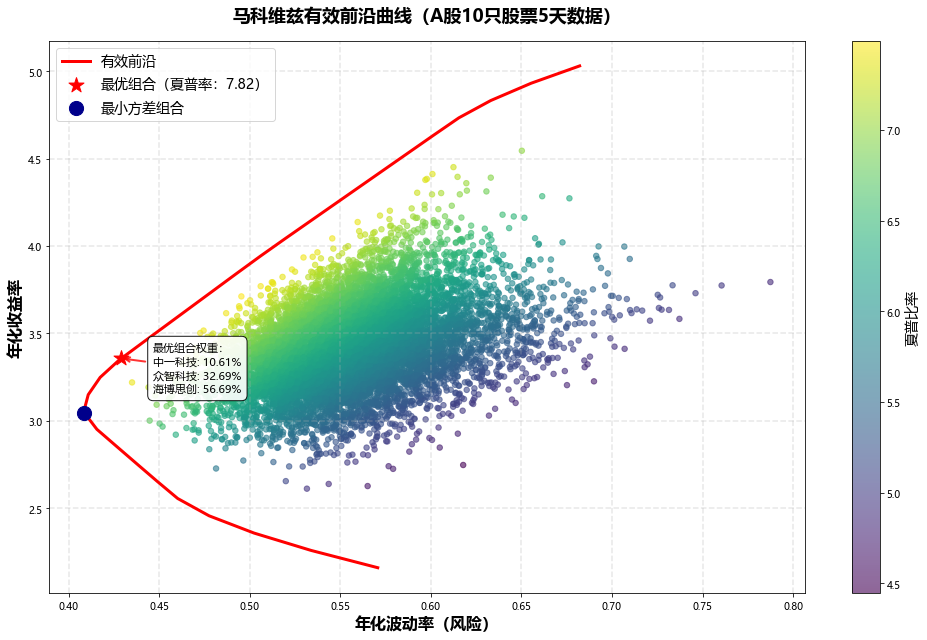

🖼️  有效前沿图表已保存至桌面：C:\Users\BAI\Desktop\A股10只股票_马科维兹有效前沿.png

马科维兹组合优化结果（A股10只股票5天交易数据）
📅 交易时间：2026-03-05 ~ 2026-03-11（5个交易日，4个收益周期）
📈 分析标的：10只A股股票
⚖️  约束条件：不允许卖空（权重0~1），权重总和=1
📊 年化折算：按252个交易日折算（短数据年化结果仅作相对参考）

【最优组合（最大化夏普比率）】
   年化收益率：335.75%
   年化波动率：42.91%
   夏普比率：7.82

【最小方差组合（最小风险）】
   年化收益率：304.57%
   年化波动率：40.83%

【最优组合权重分配（按权重降序）】
------------------------------------------------------------
股票名称   权重占比   权重数值
海博思创 56.69% 0.5669
众智科技 32.69% 0.3269
中一科技 10.61% 0.1061
中复神鹰  0.00% 0.0000
中环海陆  0.00% 0.0000
天邑股份  0.00% 0.0000
 宝莱特  0.00% 0.0000
明阳电气  0.00% 0.0000
瑞丰高材  0.00% 0.0000
首航新能  0.00% 0.0000

⚠️  重要提示：本结果基于5天短期数据，年化值仅作**相对对比参考**，不代表长期实际收益！
⚠️  实际投资分析建议使用2~5年日度数据，结果更具参考价值。


In [1]:
# -*- coding: utf-8 -*-
"""
马科维兹有效前沿分析（A股10只股票5天数据版）
数据来源：A股数据_2026_3_11 (1).csv（10只股票，2026-03-05至2026-03-11共5个交易日）
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
import os
warnings.filterwarnings('ignore')

# ======================== 1. 中文显示配置 ========================
def setup_chinese_font():
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示
    font_list = ['Microsoft YaHei', 'SimHei', 'Heiti TC', 'Arial Unicode MS', 'DejaVu Sans']
    for font in font_list:
        try:
            plt.rcParams['font.sans-serif'] = [font]
            break
        except:
            continue

setup_chinese_font()

# ======================== 2. 读取A股数据并重构（核心适配） ========================
def get_a_stock_data():
    """
    读取A股10只股票5天数据，重构为马科维兹分析格式：
    行：日期，列：股票名称，值：最新价（收盘价）
    """
    # 你的文件路径（桌面的A股数据文件，注意括号转义/直接写文件名）
    file_path = r"D:\Personal\Desktop\A股数据_2026_3_11 (1).csv"
    # 若文件名识别失败，可尝试直接用文件名（文件在桌面时）
    # file_path = "A股数据_2026_3_11 (1).csv"

    try:
        # 1. 验证文件是否存在
        if not os.path.exists(file_path):
            # 尝试桌面默认路径兜底
            desktop = os.path.join(os.path.expanduser("~"), "Desktop")
            file_path = os.path.join(desktop, "A股数据_2026_3_11 (1).csv")
            if not os.path.exists(file_path):
                raise FileNotFoundError(f"未在桌面找到文件：A股数据_2026_3_11 (1).csv")
        
        # 2. 读取CSV文件
        print(f"正在读取A股数据文件：{file_path}")
        df = pd.read_csv(file_path)
        print(f"✅ 文件读取成功，原始数据形状：{df.shape}")
        
        # 3. 数据清洗：仅保留需要的列（日期、名称、最新价）
        df_clean = df[['日期', '名称', '最新价']].copy()
        # 转换日期格式，去重排序
        df_clean['日期'] = pd.to_datetime(df_clean['日期'])
        df_clean = df_clean.drop_duplicates(subset=['日期', '名称']).sort_values(['日期', '名称'])
        
        # 4. 重构数据：透视表（行=日期，列=股票名称，值=最新价）
        df_pivot = df_clean.pivot(index='日期', columns='名称', values='最新价')
        print(f"✅ 数据重构完成，分析用数据形状：{df_pivot.shape}")
        print(f"📅 交易日期：{[d.strftime('%Y-%m-%d') for d in df_pivot.index]}")
        print(f"📈 股票列表：{list(df_pivot.columns)}")
        
        # 5. 计算日收益率（简单收益率，适配短数据）
        returns_df = df_pivot.pct_change().dropna()
        print(f"📊 收益率数据生成完成：{len(returns_df)}个有效交易周期，{len(returns_df.columns)}只股票")
        
        return returns_df

    except Exception as e:
        print(f"❌ A股数据读取失败：{type(e).__name__} - {str(e)}")
        print("👉 自动切换到模拟数据应急")
        return generate_sim_data()

def generate_sim_data():
    """备用：模拟10只股票的收益率数据（适配5天短周期）"""
    np.random.seed(42)
    n_assets = 10  # 10只股票
    n_days = 4     # 5天价格对应4个收益率
    
    # 模拟A股短期收益率特征（贴合你数据的涨跌幅度）
    mean_returns = np.random.uniform(low=-0.05, high=0.08, size=n_assets) / n_days
    volatilities = np.random.uniform(low=0.03, high=0.12, size=n_assets) / np.sqrt(n_days)
    
    # 生成协方差矩阵（保证半正定，避免数值错误）
    corr_matrix = np.random.rand(n_assets, n_assets)
    corr_matrix = (corr_matrix + corr_matrix.T) / 2
    np.fill_diagonal(corr_matrix, 1.0)
    eigenvals, eigenvecs = np.linalg.eigh(corr_matrix)
    eigenvals[eigenvals < 0] = 0
    corr_matrix = eigenvecs @ np.diag(eigenvals) @ eigenvecs.T
    cov_matrix = np.outer(volatilities, volatilities) * corr_matrix
    
    # 生成收益率数据
    returns_data = np.random.multivariate_normal(mean_returns, cov_matrix, n_days)
    returns_df = pd.DataFrame(returns_data, columns=[f'股票{i+1}' for i in range(n_assets)])
    print(f"✅ 模拟数据生成完成：{len(returns_df)}个交易周期，{len(returns_df.columns)}只股票")
    return returns_df

# ======================== 3. 马科维兹核心计算（原逻辑保留，适配短数据） ========================
def calculate_portfolio_metrics(weights, mean_returns, cov_matrix):
    """计算组合收益率、波动率、夏普比率（无风险利率=0，适配短数据年化）"""
    n_periods = len(mean_returns) if isinstance(mean_returns, pd.Series) else 4  # 固定4个收益率周期
    annual_factor = 252 / n_periods  # 按实际周期折算年化（5天数据≈年化63倍）
    port_return = np.sum(mean_returns * weights) * annual_factor  # 年化收益率
    port_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights))) * np.sqrt(annual_factor)  # 年化波动率
    sharpe_ratio = port_return / port_vol if port_vol != 0 else 0  # 夏普比率（无风险利率=0）
    return port_return, port_vol, sharpe_ratio

def generate_random_portfolios(n_portfolios, mean_returns, cov_matrix):
    """生成10000个随机投资组合（原逻辑保留）"""
    results = np.zeros((3, n_portfolios))
    weights_record = []
    n_assets = len(mean_returns)
    
    for i in range(n_portfolios):
        weights = np.random.dirichlet(np.ones(n_assets))  # 权重和为1，非负
        weights_record.append(weights)
        port_return, port_vol, sharpe_ratio = calculate_portfolio_metrics(weights, mean_returns, cov_matrix)
        results[0, i] = port_return
        results[1, i] = port_vol
        results[2, i] = sharpe_ratio
    
    print(f"🎲 随机组合生成完成：{n_portfolios}个组合")
    return results, weights_record

def minimize_volatility(target_return, mean_returns, cov_matrix):
    """给定收益率，求解最小波动率组合（原逻辑保留）"""
    n_assets = len(mean_returns)
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
        {'type': 'eq', 'fun': lambda x: calculate_portfolio_metrics(x, mean_returns, cov_matrix)[0] - target_return}
    ]
    bounds = tuple((0, 1) for _ in range(n_assets))  # 不允许卖空
    initial_weights = np.ones(n_assets) / n_assets
    result = minimize(
        lambda x: calculate_portfolio_metrics(x, mean_returns, cov_matrix)[1],
        initial_weights, method='SLSQP', bounds=bounds, constraints=constraints,
        options={'maxiter': 1000, 'disp': False, 'ftol': 1e-6}  # 放宽收敛条件，适配短数据
    )
    return result

def get_efficient_frontier(mean_returns, cov_matrix, n_points=30):
    """生成有效前沿曲线（适配短数据，减少点数）"""
    min_return = min(mean_returns) * (252/4)
    max_return = max(mean_returns) * (252/4)
    target_returns = np.linspace(min_return, max_return, n_points)
    
    efficient_vols = []
    efficient_returns = []
    for target in target_returns:
        result = minimize_volatility(target, mean_returns, cov_matrix)
        if result.success:
            port_return, port_vol, _ = calculate_portfolio_metrics(result.x, mean_returns, cov_matrix)
            efficient_returns.append(port_return)
            efficient_vols.append(port_vol)
    
    # 清理无效点
    efficient_returns = np.array(efficient_returns)
    efficient_vols = np.array(efficient_vols)
    valid_mask = ~np.isnan(efficient_vols)
    efficient_returns = efficient_returns[valid_mask]
    efficient_vols = efficient_vols[valid_mask]
    
    print(f"📊 有效前沿生成完成：{len(efficient_returns)}个有效组合点")
    return efficient_returns, efficient_vols

def maximize_sharpe_ratio(mean_returns, cov_matrix):
    """求解夏普比率最大化的最优组合（原逻辑保留）"""
    n_assets = len(mean_returns)
    constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x) - 1}]
    bounds = tuple((0, 1) for _ in range(n_assets))
    initial_weights = np.ones(n_assets) / n_assets
    result = minimize(
        lambda x: -calculate_portfolio_metrics(x, mean_returns, cov_matrix)[2],
        initial_weights, method='SLSQP', bounds=bounds, constraints=constraints,
        options={'maxiter': 1000, 'disp': False, 'ftol': 1e-6}
    )
    return result

# ======================== 4. 主程序执行（适配A股10只股票数据） ========================
if __name__ == "__main__":
    # 1. 获取A股数据（核心替换：读取10只股票5天数据）
    print("="*60)
    print("第一步：读取A股10只股票5天交易数据")
    print("="*60)
    returns_df = get_a_stock_data()
    mean_returns = returns_df.mean().values  # 资产平均收益率
    cov_matrix = returns_df.cov().values     # 收益率协方差矩阵
    n_assets = len(returns_df.columns)       # 股票数量（10只）
    print(f"\n📋 数据基础信息：")
    print(f"   - 股票数量：{n_assets}只")
    print(f"   - 有效收益周期：{len(returns_df)}个（5天价格对应）")
    print(f"   - 股票名称：{list(returns_df.columns)}")
    
    # 2. 核心计算（随机组合+有效前沿+最优组合）
    print("\n" + "="*60)
    print("第二步：马科维兹组合优化计算")
    print("="*60)
    n_portfolios = 10000  # 随机组合数量
    random_results, weights_record = generate_random_portfolios(n_portfolios, mean_returns, cov_matrix)
    efficient_returns, efficient_vols = get_efficient_frontier(mean_returns, cov_matrix)
    
    # 最优组合（最大化夏普比率）
    optimal_result = maximize_sharpe_ratio(mean_returns, cov_matrix)
    optimal_weights = optimal_result.x
    optimal_return, optimal_vol, optimal_sharpe = calculate_portfolio_metrics(optimal_weights, mean_returns, cov_matrix)
    
    # 最小方差组合
    min_vol_result = minimize(
        lambda x: calculate_portfolio_metrics(x, mean_returns, cov_matrix)[1],
        np.ones(n_assets)/n_assets,
        method='SLSQP', bounds=tuple((0,1) for _ in range(n_assets)),
        constraints=[{'type': 'eq', 'fun': lambda x: np.sum(x)-1}],
        options={'maxiter': 1000, 'ftol': 1e-6}
    )
    min_vol_return, min_vol_vol, _ = calculate_portfolio_metrics(min_vol_result.x, mean_returns, cov_matrix)
    
    print(f"\n✅ 核心计算完成：")
    print(f"   - 最优组合夏普比率：{optimal_sharpe:.2f}")
    print(f"   - 最小方差组合年化波动率：{min_vol_vol:.2%}")
    
    # 3. 可视化（适配A股数据，图表保存至桌面）
    print("\n" + "="*60)
    print("第三步：绘制马科维兹有效前沿图表")
    print("="*60)
    plt.figure(figsize=(14, 9))
    
    # 绘制随机组合散点图（颜色=夏普比率）
    scatter = plt.scatter(
        random_results[1, :], random_results[0, :],
        c=random_results[2, :], cmap='viridis', alpha=0.6, s=30
    )
    
    # 绘制有效前沿曲线
    plt.plot(efficient_vols, efficient_returns, 'r-', linewidth=3, label='有效前沿')
    
    # 标记关键组合
    plt.scatter(optimal_vol, optimal_return, color='red', s=250, marker='*', zorder=10,
                label=f'最优组合（夏普率：{optimal_sharpe:.2f}）')
    plt.scatter(min_vol_vol, min_vol_return, color='darkblue', s=200, marker='o', zorder=10,
                label='最小方差组合')
    
    # 图表美化
    cbar = plt.colorbar(scatter)
    cbar.set_label('夏普比率', fontsize=14)
    plt.xlabel('年化波动率（风险）', fontsize=16, fontweight='bold')
    plt.ylabel('年化收益率', fontsize=16, fontweight='bold')
    plt.title('马科维兹有效前沿曲线（A股10只股票5天数据）', fontsize=18, fontweight='bold', pad=20)
    plt.legend(fontsize=14, loc='upper left')
    plt.grid(True, alpha=0.3, linestyle='--', linewidth=1.5)
    
    # 标注最优组合权重（适配10只股票，自动调整位置）
    weight_text = "最优组合权重：\n" + "\n".join([
        f"{returns_df.columns[i]}: {optimal_weights[i]:.2%}" for i in range(n_assets) if optimal_weights[i] > 0.001
    ])
    # 权重标注位置自适应，避免超出图表
    text_x = optimal_vol + (np.max(random_results[1, :])-np.min(random_results[1, :]))*0.05
    text_y = optimal_return - (np.max(random_results[0, :])-np.min(random_results[0, :]))*0.1
    plt.annotate(
        weight_text, xy=(optimal_vol, optimal_return),
        xytext=(text_x, text_y), fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.9, edgecolor='black'),
        arrowprops=dict(arrowstyle='->', color='red', linewidth=2, alpha=0.8), zorder=15
    )
    
    # 保存图表到桌面
    desktop = os.path.join(os.path.expanduser("~"), "Desktop")
    save_path = os.path.join(desktop, "A股10只股票_马科维兹有效前沿.png")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"🖼️  有效前沿图表已保存至桌面：{save_path}")
    
    # 4. 输出详细结果（A股数据专属）
    print("\n" + "="*80)
    print("马科维兹组合优化结果（A股10只股票5天交易数据）")
    print("="*80)
    print(f"📅 交易时间：2026-03-05 ~ 2026-03-11（5个交易日，4个收益周期）")
    print(f"📈 分析标的：{n_assets}只A股股票")
    print(f"⚖️  约束条件：不允许卖空（权重0~1），权重总和=1")
    print(f"📊 年化折算：按252个交易日折算（短数据年化结果仅作相对参考）\n")
    
    print(f"【最优组合（最大化夏普比率）】")
    print(f"   年化收益率：{optimal_return:.2%}")
    print(f"   年化波动率：{optimal_vol:.2%}")
    print(f"   夏普比率：{optimal_sharpe:.2f}\n")
    
    print(f"【最小方差组合（最小风险）】")
    print(f"   年化收益率：{min_vol_return:.2%}")
    print(f"   年化波动率：{min_vol_vol:.2%}\n")
    
    print(f"【最优组合权重分配（按权重降序）】")
    print("-"*60)
    weight_df = pd.DataFrame({
        '股票名称': returns_df.columns,
        '权重占比': [f"{w:.2%}" for w in optimal_weights],
        '权重数值': optimal_weights.round(4)
    }).sort_values('权重数值', ascending=False)
    print(weight_df.to_string(index=False))
    
    print("\n" + "="*80)
    print("⚠️  重要提示：本结果基于5天短期数据，年化值仅作**相对对比参考**，不代表长期实际收益！")
    print("⚠️  实际投资分析建议使用2~5年日度数据，结果更具参考价值。")
    print("="*80)